In [2]:
# import libraries
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (
    BaggingClassifier, BaggingRegressor,
    AdaBoostClassifier, AdaBoostRegressor,
    GradientBoostingClassifier, GradientBoostingRegressor,
    VotingClassifier, StackingClassifier, StackingRegressor
)
from sklearn.linear_model import LogisticRegression, LinearRegression

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve,
    mean_absolute_error, mean_squared_error, r2_score
)

from lightgbm import LGBMClassifier, LGBMRegressor
from xgboost import XGBClassifier, XGBRegressor

df = pd.read_csv("dataset.5.csv")

print(df.head())
print("\nDataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing Values:")
print(df.isnull().sum())

   student_id  age country_region device_type education_background  \
0      700001   32         Europe      Laptop            Undergrad   
1      700002   17         Europe      Laptop            Undergrad   
2      700003   25         Europe      Mobile             Graduate   
3      700004   26           Asia      Mobile            Undergrad   
4      700005   26           Asia      Tablet           WorkingPro   

   course_level course_category course_start_date  week_of_year  sessions  \
0  Intermediate        Business        2024-03-18            12         1   
1  Intermediate     Programming        2024-08-22            34        16   
2      Advanced     Programming        2024-09-28            39         6   
3      Beginner          Design        2024-03-09            10        34   
4      Advanced        Business        2024-03-21            12        22   

   time_spent_hours  videos_watched  quiz_attempts  assignments_submitted  \
0               7.6               1    

In [3]:
#BASIC DATA UNDERSTANDING
print("Data Types:")
print(df.dtypes)

print("\nCompletion Status Distribution:")
print(df["completion_status"].value_counts())

print("\nFinal Score Summary:")
print(df["final_score"].describe())

Data Types:
student_id                 int64
age                        int64
country_region            object
device_type               object
education_background      object
course_level              object
course_category           object
course_start_date         object
week_of_year               int64
sessions                   int64
time_spent_hours         float64
videos_watched             int64
quiz_attempts              int64
assignments_submitted      int64
forum_posts                int64
avg_quiz_score           float64
attendance_rate          float64
completion_status          int64
final_score              float64
dtype: object

Completion Status Distribution:
completion_status
0    3248
1    1952
Name: count, dtype: int64

Final Score Summary:
count    5200.000000
mean       74.821615
std        13.531829
min        35.200000
25%        64.700000
50%        74.100000
75%        84.900000
max       100.000000
Name: final_score, dtype: float64


In [4]:
# PART B #

# Q6 - INPUT FEATURES AND TARGET VARIABLES

features = [
    "age", "country_region", "device_type", "education_background",
    "course_level", "course_category", "week_of_year", "sessions",
    "time_spent_hours", "videos_watched", "quiz_attempts",
    "assignments_submitted", "forum_posts", "avg_quiz_score",
    "attendance_rate"
]

# Classification
X_cls = df[features]
y_cls = df["completion_status"]

# Regression
X_reg = df[features]
y_reg = df["final_score"]

print("Classification Target:", y_cls.name)
print("Regression Target:", y_reg.name)
print("\nFeatures:", features)

# Q7 - BASIC PREPROCESSING

numeric_features = [
    "age", "week_of_year", "sessions", "time_spent_hours",
    "videos_watched", "quiz_attempts", "assignments_submitted",
    "forum_posts", "avg_quiz_score", "attendance_rate"
]

categorical_features = [
    "country_region", "device_type", "education_background",
    "course_level", "course_category"
]

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features)
])

print("Preprocessing completed.")

# Q8 - TRAIN TEST SPLIT

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.20, random_state=42, stratify=y_cls
)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=42
)

print("Classification Train:", X_train_cls.shape)
print("Classification Test :", X_test_cls.shape)
print("Regression Train:", X_train_reg.shape)
print("Regression Test :", X_test_reg.shape)

print("\nTrain Class Distribution:")
print(y_train_cls.value_counts(normalize=True).round(4))

Classification Target: completion_status
Regression Target: final_score

Features: ['age', 'country_region', 'device_type', 'education_background', 'course_level', 'course_category', 'week_of_year', 'sessions', 'time_spent_hours', 'videos_watched', 'quiz_attempts', 'assignments_submitted', 'forum_posts', 'avg_quiz_score', 'attendance_rate']
Preprocessing completed.
Classification Train: (4160, 15)
Classification Test : (1040, 15)
Regression Train: (4160, 15)
Regression Test : (1040, 15)

Train Class Distribution:
completion_status
0    0.6245
1    0.3755
Name: proportion, dtype: float64


In [5]:
# PART C #

# PREPROCESS BOTH TASKS

X_train_cls_p = preprocessor.fit_transform(X_train_cls)
X_test_cls_p = preprocessor.transform(X_test_cls)

X_train_reg_p = preprocessor.fit_transform(X_train_reg)
X_test_reg_p = preprocessor.transform(X_test_reg)

print("Processed Classification:", X_train_cls_p.shape)
print("Processed Regression:", X_train_reg_p.shape)

# Q9 - BAGGING CLASSIFIER

bag_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    max_samples=0.8,
    random_state=42,
    n_jobs=-1
)

bag_clf.fit(X_train_cls_p, y_train_cls)
bag_cls_pred = bag_clf.predict(X_test_cls_p)

print("Bagging Accuracy:", round(accuracy_score(y_test_cls, bag_cls_pred), 4))
print("Bagging F1:", round(f1_score(y_test_cls, bag_cls_pred), 4))

# Q10 - BAGGING REGRESSOR

bag_reg = BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=42),
    n_estimators=100,
    max_samples=0.8,
    random_state=42,
    n_jobs=-1
)

bag_reg.fit(X_train_reg_p, y_train_reg)
bag_reg_pred = bag_reg.predict(X_test_reg_p)

print("Bagging MAE:", round(mean_absolute_error(y_test_reg, bag_reg_pred), 4))
print("Bagging RMSE:", round(np.sqrt(mean_squared_error(y_test_reg, bag_reg_pred)), 4))
print("Bagging R2:", round(r2_score(y_test_reg, bag_reg_pred), 4))

# Q11 - BAGGING VS SINGLE BASE MODEL

base_clf = DecisionTreeClassifier(random_state=42)
base_clf.fit(X_train_cls_p, y_train_cls)
base_cls_pred = base_clf.predict(X_test_cls_p)

base_reg = DecisionTreeRegressor(random_state=42)
base_reg.fit(X_train_reg_p, y_train_reg)
base_reg_pred = base_reg.predict(X_test_reg_p)

comparison = pd.DataFrame({
    "Model": ["Single Decision Tree", "Bagging"],
    "Classification Accuracy": [
        accuracy_score(y_test_cls, base_cls_pred),
        accuracy_score(y_test_cls, bag_cls_pred)
    ],
    "Regression RMSE": [
        np.sqrt(mean_squared_error(y_test_reg, base_reg_pred)),
        np.sqrt(mean_squared_error(y_test_reg, bag_reg_pred))
    ],
    "Regression R2": [
        r2_score(y_test_reg, base_reg_pred),
        r2_score(y_test_reg, bag_reg_pred)
    ]
})

print(comparison.round(4))

Processed Classification: (4160, 30)
Processed Regression: (4160, 30)
Bagging Accuracy: 0.7221
Bagging F1: 0.6057
Bagging MAE: 8.0466
Bagging RMSE: 10.0406
Bagging R2: 0.4604
                  Model  Classification Accuracy  Regression RMSE  \
0  Single Decision Tree                   0.6298          14.3772   
1               Bagging                   0.7221          10.0406   

   Regression R2  
0        -0.1063  
1         0.4604  


AdaBoost Accuracy: 0.7365
AdaBoost F1: 0.6074
AdaBoost MAE: 8.5452
AdaBoost RMSE: 10.5174
AdaBoost R2: 0.408


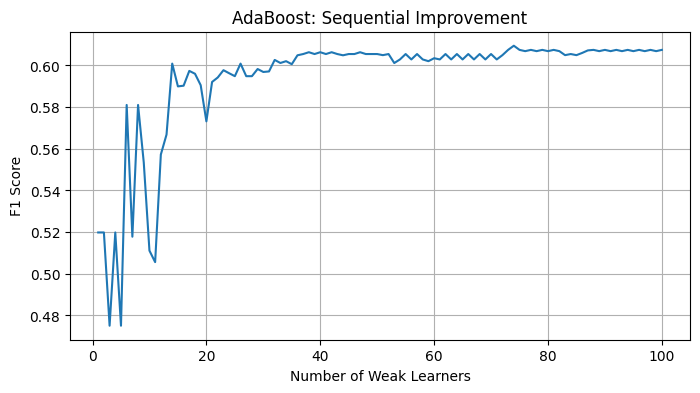

Gradient Boosting Accuracy: 0.7385
Gradient Boosting F1: 0.618
Gradient Boosting MAE: 7.9645
Gradient Boosting RMSE: 9.919
Gradient Boosting R2: 0.4734
   Learning Rate  Estimators  Accuracy      F1
0           0.01          50    0.6692  0.2863
1           0.01         100    0.6990  0.4809
2           0.01         200    0.7308  0.5846
3           0.05          50    0.7317  0.5951
4           0.05         100    0.7385  0.6180
5           0.05         200    0.7356  0.6207
6           0.10          50    0.7365  0.6152
7           0.10         100    0.7385  0.6253
8           0.10         200    0.7250  0.6093
LightGBM Accuracy: 0.7288
LightGBM F1: 0.6061
LightGBM MAE: 7.9309
LightGBM RMSE: 9.8756
LightGBM R2: 0.478
Dataset Rows: 5200
LightGBM Classifier Estimators: 100
LightGBM Regressor Estimators: 100

LightGBM is designed for efficient gradient boosting and scalability.
XGBoost Accuracy: 0.7356
XGBoost F1: 0.6196
XGBoost MAE: 7.9205
XGBoost RMSE: 9.8749
XGBoost R2: 0.4781
BOOST

In [6]:
# PART D #

# Q12 - ADABOOST CLASSIFIER

ada_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

ada_clf.fit(X_train_cls_p, y_train_cls)
ada_cls_pred = ada_clf.predict(X_test_cls_p)

print("AdaBoost Accuracy:", round(accuracy_score(y_test_cls, ada_cls_pred), 4))
print("AdaBoost F1:", round(f1_score(y_test_cls, ada_cls_pred), 4))

# Q13 - ADABOOST REGRESSOR

ada_reg = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=3, random_state=42),
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

ada_reg.fit(X_train_reg_p, y_train_reg)
ada_reg_pred = ada_reg.predict(X_test_reg_p)

print("AdaBoost MAE:", round(mean_absolute_error(y_test_reg, ada_reg_pred), 4))
print("AdaBoost RMSE:", round(np.sqrt(mean_squared_error(y_test_reg, ada_reg_pred)), 4))
print("AdaBoost R2:", round(r2_score(y_test_reg, ada_reg_pred), 4))

# Q14 - WEAK LEARNERS IMPROVE SEQUENTIALLY

staged_f1 = []
for pred in ada_clf.staged_predict(X_test_cls_p):
    staged_f1.append(f1_score(y_test_cls, pred))

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(staged_f1) + 1), staged_f1)
plt.title("AdaBoost: Sequential Improvement")
plt.xlabel("Number of Weak Learners")
plt.ylabel("F1 Score")
plt.grid()
plt.show()

# GRADIEBT BOOSTING #

# Q15 - GRADIENT BOOSTING CLASSIFIER

gb_clf = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_clf.fit(X_train_cls_p, y_train_cls)
gb_cls_pred = gb_clf.predict(X_test_cls_p)

print("Gradient Boosting Accuracy:", round(accuracy_score(y_test_cls, gb_cls_pred), 4))
print("Gradient Boosting F1:", round(f1_score(y_test_cls, gb_cls_pred), 4))

# Q16 - GRADIENT BOOSTING REGRESSOR

gb_reg = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_reg.fit(X_train_reg_p, y_train_reg)
gb_reg_pred = gb_reg.predict(X_test_reg_p)

print("Gradient Boosting MAE:", round(mean_absolute_error(y_test_reg, gb_reg_pred), 4))
print("Gradient Boosting RMSE:", round(np.sqrt(mean_squared_error(y_test_reg, gb_reg_pred)), 4))
print("Gradient Boosting R2:", round(r2_score(y_test_reg, gb_reg_pred), 4))

# Q17 - LEARNING RATE AND NUMBER OF ESTIMATORS

gb_tuning_results = []

for lr in [0.01, 0.05, 0.10]:
    for n in [50, 100, 200]:
        model = GradientBoostingClassifier(
            n_estimators=n, learning_rate=lr,
            max_depth=3, random_state=42
        )
        model.fit(X_train_cls_p, y_train_cls)
        pred = model.predict(X_test_cls_p)

        gb_tuning_results.append([
            lr, n,
            accuracy_score(y_test_cls, pred),
            f1_score(y_test_cls, pred)
        ])

gb_tuning_df = pd.DataFrame(
    gb_tuning_results,
    columns=["Learning Rate", "Estimators", "Accuracy", "F1"]
)

print(gb_tuning_df.round(4))

# LIGHTGBM CLASSIFIER #

# Q18 - LIGHTGBM CLASSIFIER

lgb_clf = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    random_state=42,
    verbosity=-1
)

lgb_clf.fit(X_train_cls_p, y_train_cls)
lgb_cls_pred = lgb_clf.predict(X_test_cls_p)

print("LightGBM Accuracy:", round(accuracy_score(y_test_cls, lgb_cls_pred), 4))
print("LightGBM F1:", round(f1_score(y_test_cls, lgb_cls_pred), 4))

# Q19 - LIGHTGBM REGRESSOR

lgb_reg = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.05,
    random_state=42,
    verbosity=-1
)

lgb_reg.fit(X_train_reg_p, y_train_reg)
lgb_reg_pred = lgb_reg.predict(X_test_reg_p)

print("LightGBM MAE:", round(mean_absolute_error(y_test_reg, lgb_reg_pred), 4))
print("LightGBM RMSE:", round(np.sqrt(mean_squared_error(y_test_reg, lgb_reg_pred)), 4))
print("LightGBM R2:", round(r2_score(y_test_reg, lgb_reg_pred), 4))

# Q20 - PERFORMANCE AND TRAINING EFFICIENCY

print("Dataset Rows:", len(df))
print("LightGBM Classifier Estimators:", lgb_clf.n_estimators)
print("LightGBM Regressor Estimators:", lgb_reg.n_estimators)
print("\nLightGBM is designed for efficient gradient boosting and scalability.")

# XGBOOST CLASSIFIER #

# Q21 - XGBOOST CLASSIFIER

xgb_clf = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_clf.fit(X_train_cls_p, y_train_cls)
xgb_cls_pred = xgb_clf.predict(X_test_cls_p)
xgb_cls_prob = xgb_clf.predict_proba(X_test_cls_p)[:, 1]

print("XGBoost Accuracy:", round(accuracy_score(y_test_cls, xgb_cls_pred), 4))
print("XGBoost F1:", round(f1_score(y_test_cls, xgb_cls_pred), 4))

# Q22 - XGBOOST REGRESSOR

xgb_reg = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_reg.fit(X_train_reg_p, y_train_reg)
xgb_reg_pred = xgb_reg.predict(X_test_reg_p)

print("XGBoost MAE:", round(mean_absolute_error(y_test_reg, xgb_reg_pred), 4))
print("XGBoost RMSE:", round(np.sqrt(mean_squared_error(y_test_reg, xgb_reg_pred)), 4))
print("XGBoost R2:", round(r2_score(y_test_reg, xgb_reg_pred), 4))

# Q23 - BOOSTING MODEL COMPARISON

boosting_cls = pd.DataFrame([
    ["AdaBoost", accuracy_score(y_test_cls, ada_cls_pred), precision_score(y_test_cls, ada_cls_pred), recall_score(y_test_cls, ada_cls_pred), f1_score(y_test_cls, ada_cls_pred)],
    ["Gradient Boosting", accuracy_score(y_test_cls, gb_cls_pred), precision_score(y_test_cls, gb_cls_pred), recall_score(y_test_cls, gb_cls_pred), f1_score(y_test_cls, gb_cls_pred)],
    ["LightGBM", accuracy_score(y_test_cls, lgb_cls_pred), precision_score(y_test_cls, lgb_cls_pred), recall_score(y_test_cls, lgb_cls_pred), f1_score(y_test_cls, lgb_cls_pred)],
    ["XGBoost", accuracy_score(y_test_cls, xgb_cls_pred), precision_score(y_test_cls, xgb_cls_pred), recall_score(y_test_cls, xgb_cls_pred), f1_score(y_test_cls, xgb_cls_pred)]
], columns=["Model", "Accuracy", "Precision", "Recall", "F1"])

boosting_reg = pd.DataFrame([
    ["AdaBoost", mean_absolute_error(y_test_reg, ada_reg_pred), np.sqrt(mean_squared_error(y_test_reg, ada_reg_pred)), r2_score(y_test_reg, ada_reg_pred)],
    ["Gradient Boosting", mean_absolute_error(y_test_reg, gb_reg_pred), np.sqrt(mean_squared_error(y_test_reg, gb_reg_pred)), r2_score(y_test_reg, gb_reg_pred)],
    ["LightGBM", mean_absolute_error(y_test_reg, lgb_reg_pred), np.sqrt(mean_squared_error(y_test_reg, lgb_reg_pred)), r2_score(y_test_reg, lgb_reg_pred)],
    ["XGBoost", mean_absolute_error(y_test_reg, xgb_reg_pred), np.sqrt(mean_squared_error(y_test_reg, xgb_reg_pred)), r2_score(y_test_reg, xgb_reg_pred)]
], columns=["Model", "MAE", "RMSE", "R2"])

print("BOOSTING CLASSIFICATION")
print(boosting_cls.round(4))
print("\nBOOSTING REGRESSION")
print(boosting_reg.round(4))


In [7]:
# PART E #

# Q24 - VOTING CLASSIFIER

vote_estimators = [
    ("lr", LogisticRegression(max_iter=1000, random_state=42)),
    ("dt", DecisionTreeClassifier(max_depth=5, random_state=42)),
    ("gb", GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.05, random_state=42
    ))
]

hard_voting = VotingClassifier(estimators=vote_estimators, voting="hard")
soft_voting = VotingClassifier(estimators=vote_estimators, voting="soft")

hard_voting.fit(X_train_cls_p, y_train_cls)
soft_voting.fit(X_train_cls_p, y_train_cls)

hard_pred = hard_voting.predict(X_test_cls_p)
soft_pred = soft_voting.predict(X_test_cls_p)
soft_prob = soft_voting.predict_proba(X_test_cls_p)[:, 1]

print("Hard Voting Accuracy:", round(accuracy_score(y_test_cls, hard_pred), 4))
print("Soft Voting Accuracy:", round(accuracy_score(y_test_cls, soft_pred), 4))

# Q25 - HARD VOTING VS SOFT VOTING

voting_comparison = pd.DataFrame([
    ["Hard Voting", accuracy_score(y_test_cls, hard_pred), precision_score(y_test_cls, hard_pred), recall_score(y_test_cls, hard_pred), f1_score(y_test_cls, hard_pred)],
    ["Soft Voting", accuracy_score(y_test_cls, soft_pred), precision_score(y_test_cls, soft_pred), recall_score(y_test_cls, soft_pred), f1_score(y_test_cls, soft_pred)]
], columns=["Voting", "Accuracy", "Precision", "Recall", "F1"])

print(voting_comparison.round(4))

# Q26 - STACKING CLASSIFIER

stack_clf = StackingClassifier(
    estimators=[
        ("lr", LogisticRegression(max_iter=1000, random_state=42)),
        ("dt", DecisionTreeClassifier(max_depth=5, random_state=42)),
        ("gb", GradientBoostingClassifier(
            n_estimators=100, learning_rate=0.05, random_state=42
        ))
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5
)

stack_clf.fit(X_train_cls_p, y_train_cls)
stack_cls_pred = stack_clf.predict(X_test_cls_p)
stack_cls_prob = stack_clf.predict_proba(X_test_cls_p)[:, 1]

print("Stacking Accuracy:", round(accuracy_score(y_test_cls, stack_cls_pred), 4))
print("Stacking F1:", round(f1_score(y_test_cls, stack_cls_pred), 4))

# Q27 - STACKING REGRESSOR

stack_reg = StackingRegressor(
    estimators=[
        ("dt", DecisionTreeRegressor(max_depth=5, random_state=42)),
        ("gb", GradientBoostingRegressor(
            n_estimators=100, learning_rate=0.05, random_state=42
        )),
        ("lr", LinearRegression())
    ],
    final_estimator=LinearRegression(),
    cv=5
)

stack_reg.fit(X_train_reg_p, y_train_reg)
stack_reg_pred = stack_reg.predict(X_test_reg_p)

print("Stacking MAE:", round(mean_absolute_error(y_test_reg, stack_reg_pred), 4))
print("Stacking RMSE:", round(np.sqrt(mean_squared_error(y_test_reg, stack_reg_pred)), 4))
print("Stacking R2:", round(r2_score(y_test_reg, stack_reg_pred), 4))

Hard Voting Accuracy: 0.7413
Soft Voting Accuracy: 0.7346
        Voting  Accuracy  Precision  Recall      F1
0  Hard Voting    0.7413     0.6921   0.559  0.6184
1  Soft Voting    0.7346     0.6770   0.559  0.6124
Stacking Accuracy: 0.7442
Stacking F1: 0.6316
Stacking MAE: 7.8049
Stacking RMSE: 9.7166
Stacking R2: 0.4947


                  Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
8              Stacking    0.7442     0.6867  0.5846    0.6316   0.7940
5               XGBoost    0.7356     0.6727  0.5744    0.6196   0.7875
6           Hard Voting    0.7413     0.6921  0.5590    0.6184      NaN
3     Gradient Boosting    0.7385     0.6832  0.5641    0.6180   0.7896
7           Soft Voting    0.7346     0.6770  0.5590    0.6124   0.7891
2              AdaBoost    0.7365     0.6883  0.5436    0.6074   0.7850
4              LightGBM    0.7288     0.6656  0.5564    0.6061   0.7805
1               Bagging    0.7221     0.6472  0.5692    0.6057   0.7739
0  Single Decision Tree    0.6298     0.5062  0.5256    0.5157   0.6090


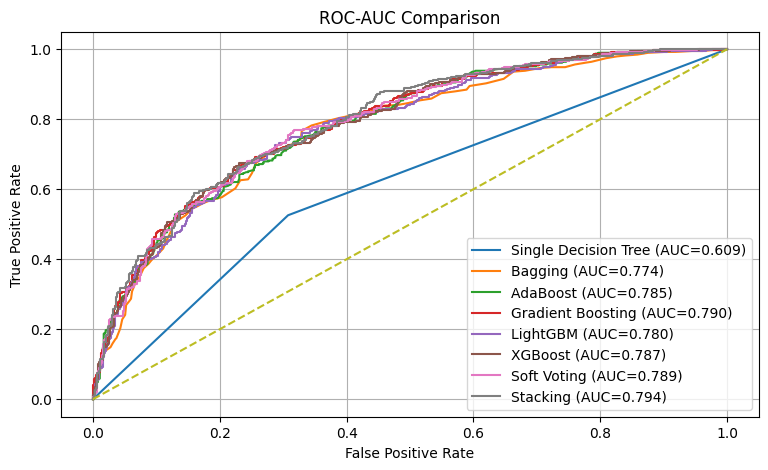

                  Model      MAE     RMSE  R2 Score
6              Stacking   7.8049   9.7166    0.4947
5               XGBoost   7.9205   9.8749    0.4781
4              LightGBM   7.9309   9.8756    0.4780
3     Gradient Boosting   7.9645   9.9190    0.4734
1               Bagging   8.0466  10.0406    0.4604
2              AdaBoost   8.5452  10.5174    0.4080
0  Single Decision Tree  11.3110  14.3772   -0.1063
🏆 BEST CLASSIFICATION MODEL
Model       : Stacking
Accuracy    : 0.7442
Precision   : 0.6867
Recall      : 0.5846
F1 Score    : 0.6316
ROC-AUC     : 0.794

🏆 BEST REGRESSION MODEL
Model       : Stacking
MAE         : 7.8049
RMSE        : 9.7166
R2 Score    : 0.4947


In [10]:
# PART F #

# Q28 - CLASSIFICATION EVALUATION

classification_predictions = {
    "Single Decision Tree": (base_cls_pred, base_clf.predict_proba(X_test_cls_p)[:, 1]),
    "Bagging": (bag_cls_pred, bag_clf.predict_proba(X_test_cls_p)[:, 1]),
    "AdaBoost": (ada_cls_pred, ada_clf.predict_proba(X_test_cls_p)[:, 1]),
    "Gradient Boosting": (gb_cls_pred, gb_clf.predict_proba(X_test_cls_p)[:, 1]),
    "LightGBM": (lgb_cls_pred, lgb_clf.predict_proba(X_test_cls_p)[:, 1]),
    "XGBoost": (xgb_cls_pred, xgb_cls_prob),
    "Hard Voting": (hard_pred, None),
    "Soft Voting": (soft_pred, soft_prob),
    "Stacking": (stack_cls_pred, stack_cls_prob)
}

classification_results = []

for name, (pred, prob) in classification_predictions.items():
    auc = roc_auc_score(y_test_cls, prob) if prob is not None else np.nan
    classification_results.append([
        name,
        accuracy_score(y_test_cls, pred),
        precision_score(y_test_cls, pred),
        recall_score(y_test_cls, pred),
        f1_score(y_test_cls, pred),
        auc
    ])

classification_df = pd.DataFrame(
    classification_results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
)

print(classification_df.sort_values("F1 Score", ascending=False).round(4))

# ROC-AUC CURVE

plt.figure(figsize=(9, 5))

for name, (pred, prob) in classification_predictions.items():
    if prob is not None:
        fpr, tpr, _ = roc_curve(y_test_cls, prob)
        auc = roc_auc_score(y_test_cls, prob)
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC-AUC Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()

# Q29 - REGRESSION EVALUATION

regression_predictions = {
    "Single Decision Tree": base_reg_pred,
    "Bagging": bag_reg_pred,
    "AdaBoost": ada_reg_pred,
    "Gradient Boosting": gb_reg_pred,
    "LightGBM": lgb_reg_pred,
    "XGBoost": xgb_reg_pred,
    "Stacking": stack_reg_pred
}

regression_results = []

for name, pred in regression_predictions.items():
    regression_results.append([
        name,
        mean_absolute_error(y_test_reg, pred),
        np.sqrt(mean_squared_error(y_test_reg, pred)),
        r2_score(y_test_reg, pred)
    ])

regression_df = pd.DataFrame(
    regression_results,
    columns=["Model", "MAE", "RMSE", "R2 Score"]
)

print(regression_df.sort_values("R2 Score", ascending=False).round(4))

# Q30 - BEST PERFORMING MODEL


best_cls_row = classification_df.loc[
    classification_df["F1 Score"].idxmax()
]

best_reg_row = regression_df.loc[
    regression_df["R2 Score"].idxmax()
]

print("🏆 BEST CLASSIFICATION MODEL")
print("Model       :", best_cls_row["Model"])
print("Accuracy    :", round(best_cls_row["Accuracy"], 4))
print("Precision   :", round(best_cls_row["Precision"], 4))
print("Recall      :", round(best_cls_row["Recall"], 4))
print("F1 Score    :", round(best_cls_row["F1 Score"], 4))
print("ROC-AUC     :", round(best_cls_row["ROC-AUC"], 4))

print("\n🏆 BEST REGRESSION MODEL")
print("Model       :", best_reg_row["Model"])
print("MAE         :", round(best_reg_row["MAE"], 4))
print("RMSE        :", round(best_reg_row["RMSE"], 4))
print("R2 Score    :", round(best_reg_row["R2 Score"], 4))

In [9]:
# PART G #

# Q31 - FINAL ANALYSIS

print("""
FINAL PROJECT ANALYSIS
======================

1. BAGGING
   Uses bootstrap samples and combines multiple models.
   Main benefit: reduces variance and improves stability.

2. ADABOOST
   Builds weak learners sequentially.
   Later learners focus more on difficult observations.

3. GRADIENT BOOSTING
   Builds trees sequentially to reduce previous errors.
   Learning rate and estimators strongly affect performance.

4. LIGHTGBM
   Efficient gradient boosting framework designed for speed
   and scalability.

5. XGBOOST
   Powerful regularized boosting algorithm with strong
   predictive performance.

6. VOTING
   Combines multiple classifiers.
   Hard Voting uses majority class.
   Soft Voting uses predicted probabilities.

7. STACKING
   Base models produce predictions and a meta-learner learns
   how to combine them.

8. CLASSIFICATION
   Accuracy, Precision, Recall, F1 and ROC-AUC are used.

9. REGRESSION
   MAE and RMSE measure prediction error.
   R2 measures explained variance.

10. DEPLOYMENT
   Choose the classification model using the most important
   business metric and the regression model using low error
   and high R2.
""")

print("Best Classification:", best_cls_row["Model"])
print("Best Classification F1:", round(best_cls_row["F1 Score"], 4))
print("Best Regression:", best_reg_row["Model"])
print("Best Regression R2:", round(best_reg_row["R2 Score"], 4))

# Q32 - FINAL SUBMISSION CHECKLIST

checklist = [
    "Dataset loaded",
    "Classification target identified: completion_status",
    "Regression target identified: final_score",
    "Train/Test split completed",
    "Encoding + scaling completed",
    "Bagging Classifier implemented",
    "Bagging Regressor implemented",
    "Bagging vs base model compared",
    "AdaBoost Classifier implemented",
    "AdaBoost Regressor implemented",
    "Weak learner improvement analyzed",
    "Gradient Boosting Classifier implemented",
    "Gradient Boosting Regressor implemented",
    "Learning rate / estimators analyzed",
    "LightGBM Classifier implemented",
    "LightGBM Regressor implemented",
    "LightGBM efficiency discussed",
    "XGBoost Classifier implemented",
    "XGBoost Regressor implemented",
    "Boosting models compared",
    "Voting Classifier implemented",
    "Hard Voting vs Soft Voting compared",
    "Stacking Classifier implemented",
    "Stacking Regressor implemented",
    "Classification metrics evaluated",
    "Regression metrics evaluated",
    "Best models identified",
    "Final analysis prepared"
]

for item in checklist:
    print("✓", item)


FINAL PROJECT ANALYSIS

1. BAGGING
   Uses bootstrap samples and combines multiple models.
   Main benefit: reduces variance and improves stability.

2. ADABOOST
   Builds weak learners sequentially.
   Later learners focus more on difficult observations.

3. GRADIENT BOOSTING
   Builds trees sequentially to reduce previous errors.
   Learning rate and estimators strongly affect performance.

4. LIGHTGBM
   Efficient gradient boosting framework designed for speed
   and scalability.

5. XGBOOST
   Powerful regularized boosting algorithm with strong
   predictive performance.

6. VOTING
   Combines multiple classifiers.
   Hard Voting uses majority class.
   Soft Voting uses predicted probabilities.

7. STACKING
   Base models produce predictions and a meta-learner learns
   how to combine them.

8. CLASSIFICATION
   Accuracy, Precision, Recall, F1 and ROC-AUC are used.

9. REGRESSION
   MAE and RMSE measure prediction error.
   R2 measures explained variance.

10. DEPLOYMENT
   Choose